# Exploratory SNA, chapter 3


This notebook provides a Python transcription of the analyses presented in Chapter 3 of the book: Wouter de Nooy / Andrej Mrvar / Vladimir Batagelj, _Exploratory Social Network Analysis with Pajek_, Third edition, Cambridge: Cambridge University Press, 2018. 


It reuses the same data about visiting relations between families living in haciendas (farms).

The cohesive subgroups are compared to six family–friendship groupings defined by researchers.




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import pprint as pprint

In [ ]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [49]:
import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')

In [50]:
import network_analysis_functions as naf

In [51]:
print(reload(naf))

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/sciences_historiques_numeriques/histoire_numerique_methodes/analyse_reseaux/pajek_book/../network_analysis_functions.py'>


In [ ]:
### Open a Pajek file

f = '../data/Chapter3/Attiro.net'
G = nx.read_pajek(f)

## MultiDiGraph: Directed graphs with self loops and parallel edges
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html#networkx.MultiDiGraph
print(type(G))

In [8]:
### Use the custom function to inspect the graph properties
naf.basic_properties(G)

{'is_multigraph': True,
 'is_directed': True,
 'number_of_nodes': 60,
 'number_of_edges': 161,
 '------': '------',
 'is connected': False,
 'components': 2,
 'density': 0.045480225988700565}


Exploratory SNA, p.75:

* Density is the number of lines in a simple network divided by the number of maximum possible number of lines.
* A complete network is a network with maximum density.
* Density is inversely related to network size: the more nodes you have in the network, the less connected they are in general

In [ ]:
### Inspect properties of nodes and edges
print(list(G.nodes.data())[:5])
print('-')
## Noter le dernier doublon de relations
print(list(G.edges.data())[-5:])

In [9]:
### Count the types of visiting relation,
# expressed by the weight property:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in G.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

1.0    118
2.0     37
3.0      6
dtype: int64


In [ ]:
### Remove the attributes listed below from all nodes
attrs_to_remove = ['x', 'y', 'shape', 'id']

# Custom funtion in local namespace naf
naf.remove_node_attributes(G, attrs_to_remove)

print(list(G.nodes.data())[:5])

[('f1', {}), ('f2', {}), ('f3', {}), ('f4', {}), ('f6', {})]


In [13]:
### List of nodes' identifiers
nodes = list(G.nodes.keys())
print(nodes[:3])

['f1', 'f2', 'f3']


In [14]:
### Open the clusters file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter3/Attiro_grouping.clu'
cluster= pd.read_csv(f)
l = list(cluster["*Vertices 60"])
ln = list(zip(nodes,l))
print(ln[:3])


[('f1', 0), ('f2', 0), ('f3', 0)]


In [15]:
### Prepare the family clusters to add to the nodes
friends = dict([(d[0], {'friends': d[1]}) for d in ln])

### Add the family clusters to the nodes
nx.set_node_attributes(G, friends)

print(list(G.nodes.data())[:3])

[('f1', {'friends': 0}), ('f2', {'friends': 0}), ('f3', {'friends': 0})]


Distribution of families per friendship group: 

0     23
1      4
4      9
5      5
7      4
10    15
dtype: int64


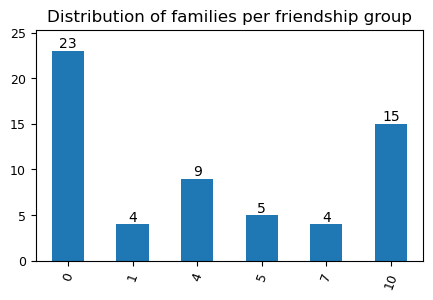

In [16]:
### Group and count families belonging to the same friends group

fig, ax = plt.subplots()

l = [n[1]['friends'] for n in G.nodes.data()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()

## there are families missing, cf. the identifiers
print('Distribution of families per friendship group: \n\n' + str(grouped))

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(5,3))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.margins(0.1, 0.1)
plt.show()


In [18]:
colors = [
     "#6699CC",  # Sky Blue
    "#FFC0CB",  # Light Pink
    "#FF99CC",  # Pastel Pink
    "#FF69B4",  # Hot Pink
    "#FF33CC",  # Bright Pink
    "#CC33CC",  # Pastel Purple
    "#CC66CC",  # Light Purple
    "#00CCCC",  # Pale Turquoise
    "#33CCFF",  # Light Blue
    "#9966CC",  # Soft Purple
    "#00CC66",  # Mint Green
]

In [19]:
### The color is chosen using the friendship group value
# as an index in slicing the colors list
node_colors = [colors[G.nodes[n]['friends']] for n in G.nodes]
print(node_colors[:3])

['#6699CC', '#6699CC', '#6699CC']


In [20]:
print(list(G.nodes.data())[10:20])

[('f35', {'friends': 4}), ('f36', {'friends': 0}), ('f37', {'friends': 0}), ('f41', {'friends': 7}), ('f42', {'friends': 0}), ('f43', {'friends': 7}), ('f44', {'friends': 0}), ('f45', {'friends': 0}), ('f46', {'friends': 5}), ('f47', {'friends': 5})]


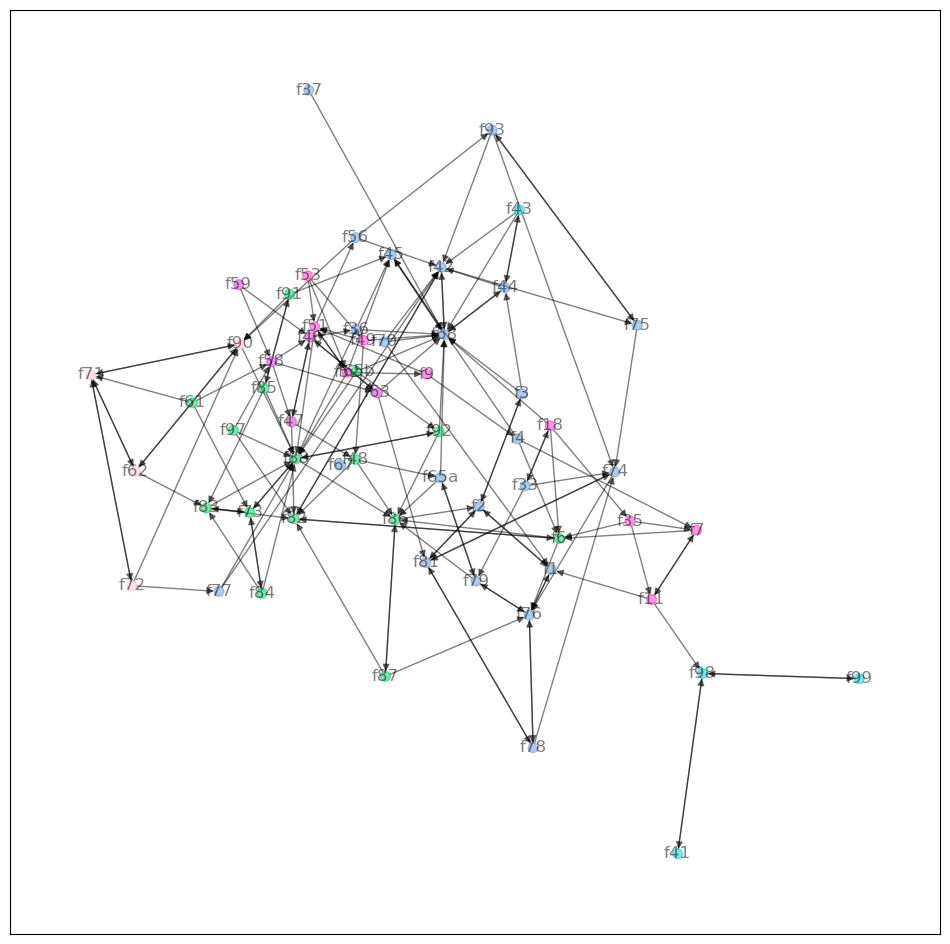

In [21]:
### Draw the network


plt.figure(figsize = (12,12))
pos = nx.kamada_kawai_layout(G)
nx.draw_networkx(G, pos, node_size=50, node_color=node_colors, alpha=0.5)


In [22]:
### Filter edges values according to weight value
# Weight of 2: kins
filtered_edges = [(u, v) for u,v,e in G.edges(data=True) if e['weight'] == 2.0]
filtered_edges[:3]


[('f4', 'f45'), ('f4', 'f7'), ('f37', 'f68')]

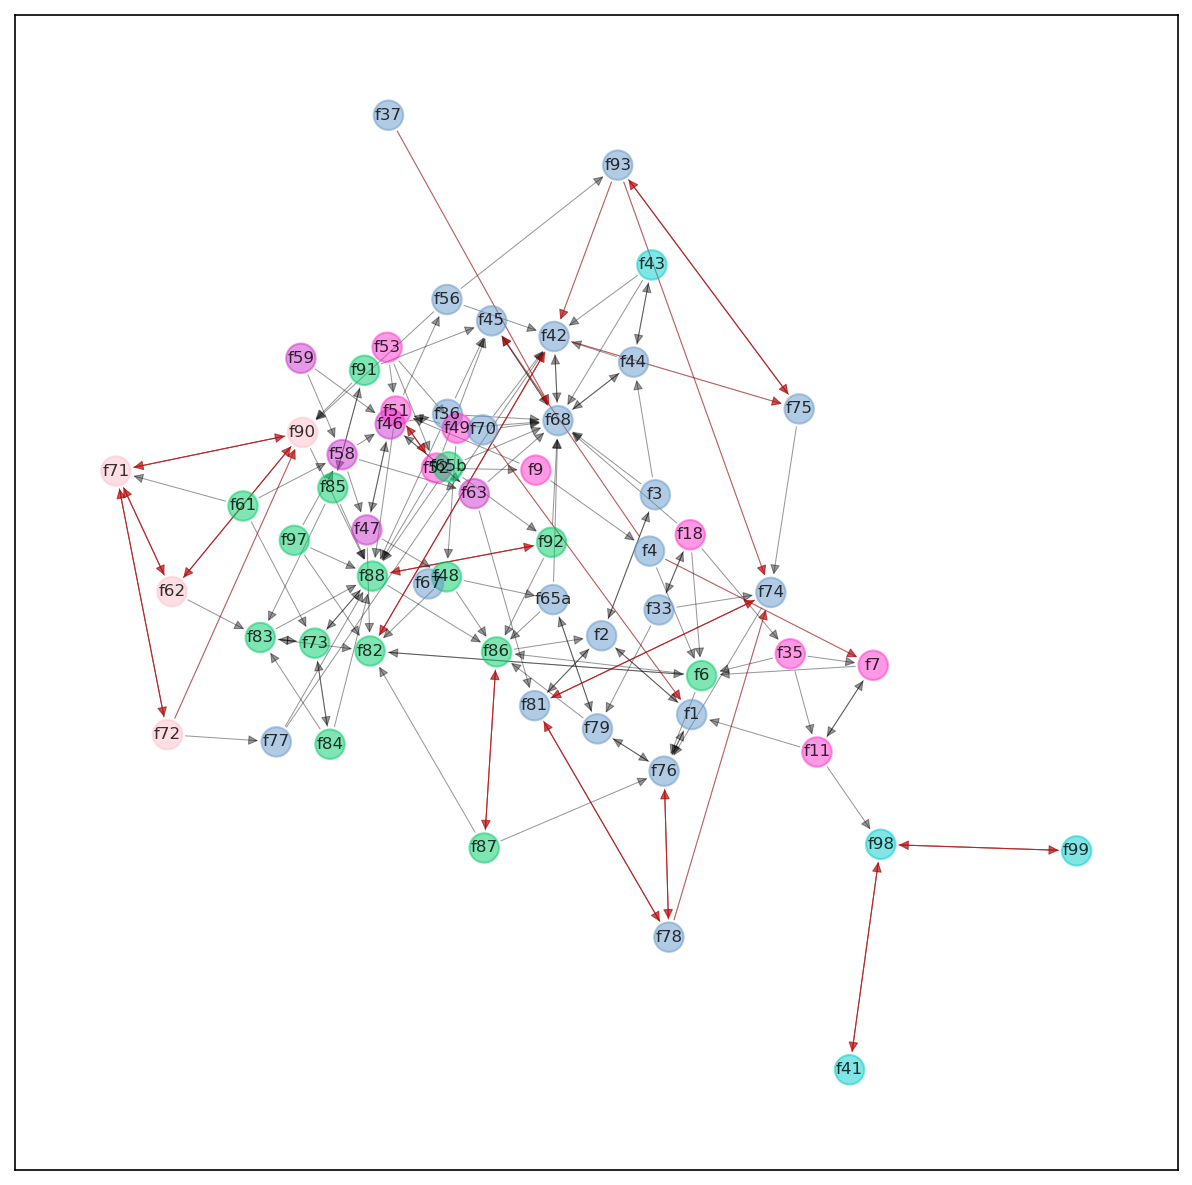

In [34]:
### Customize plot and add blue edges for the visiting kins

plt.figure(figsize = (10,10), dpi=150)
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'red'
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8, alpha=0.8)
nx.draw_networkx_edges(G, pos,  width=0.5, alpha=0.4)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=0.5, edge_color=c, alpha=0.4)

plt.show()

### Degree of nodes

Exploratory SNA, p. 76:

* The degree of a vertex is the number of lines incident with it.
* Two vertices are adjacent if they are connected by a line.
* The indegree of a vertex is the number of arcs it receives.
* The outdegree is the number of arcs it sends.

#### Indegree

In [54]:
### Calculate the indegree for all nodes
print(list(G.in_degree())[:5])

l_id = [d[1] for d in G.in_degree()]
il=l_id
print(il[:3])

[('f1', 4), ('f2', 4), ('f3', 1), ('f4', 1), ('f6', 5)]
[4, 4, 1]


count    60.000000
mean      2.683333
std       2.733915
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      14.000000
dtype: float64


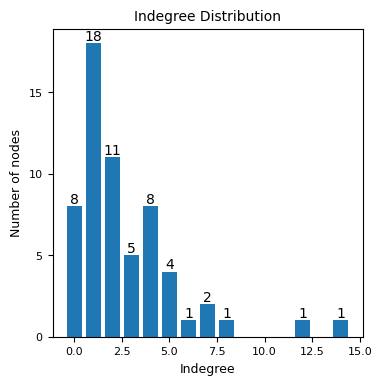

In [55]:
naf.describe_plot_integers_distribution(il, 4,4)

count    60.000000
mean      2.683333
std       2.733915
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      14.000000
dtype: float64


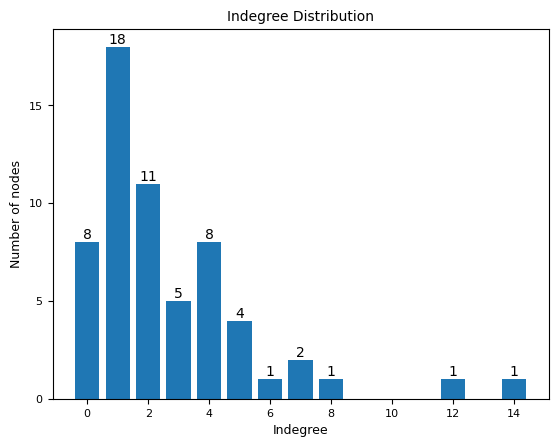

In [36]:
sl_id = pd.Series(l_id)
print(sl_id.describe())

## Distribution of the indegree
df_l = pd.DataFrame(sl_id.groupby(by=sl_id).size().items())
df_l.columns=['value', 'number']

fig, ax = plt.subplots()

plt.bar  (df_l.value, df_l.number)

ax.yaxis.get_major_locator().set_params(integer=True)
ax.bar_label(ax.containers[-1])
plt.xticks(size=8)
plt.xlabel('Indegree', size=9)
plt.yticks(size=8)
plt.ylabel('Number of nodes', size=9)
plt.title('Indegree Distribution', size=10)

#plt.close()

plt.show()

In [ ]:
## Format the indegree in order to add it to the nodes
indegree = dict([(d[0], {'indegree': d[1]}) for d in G.in_degree()])

## Add the indegree to the nodes
nx.set_node_attributes(G, indegree)

print(list(G.nodes.data())[:3])


#### Outdegree

In [ ]:
### Calculate the indegree for all nodes
print(list(G.out_degree())[:5])

l_od = [d[1] for d in G.out_degree()]
print(l_od[:3])

In [37]:
outdegree = dict([(d[0], {'outdegree': d[1]}) for d in G.out_degree()])
print(outdegree)

{'f1': {'outdegree': 2}, 'f2': {'outdegree': 3}, 'f3': {'outdegree': 3}, 'f4': {'outdegree': 3}, 'f6': {'outdegree': 3}, 'f7': {'outdegree': 2}, 'f9': {'outdegree': 2}, 'f11': {'outdegree': 3}, 'f18': {'outdegree': 4}, 'f33': {'outdegree': 3}, 'f35': {'outdegree': 3}, 'f36': {'outdegree': 3}, 'f37': {'outdegree': 1}, 'f41': {'outdegree': 1}, 'f42': {'outdegree': 3}, 'f43': {'outdegree': 3}, 'f44': {'outdegree': 3}, 'f45': {'outdegree': 1}, 'f46': {'outdegree': 3}, 'f47': {'outdegree': 3}, 'f48': {'outdegree': 3}, 'f49': {'outdegree': 3}, 'f51': {'outdegree': 3}, 'f52': {'outdegree': 4}, 'f53': {'outdegree': 3}, 'f56': {'outdegree': 3}, 'f58': {'outdegree': 3}, 'f59': {'outdegree': 2}, 'f61': {'outdegree': 3}, 'f62': {'outdegree': 3}, 'f63': {'outdegree': 3}, 'f65a': {'outdegree': 3}, 'f65b': {'outdegree': 3}, 'f67': {'outdegree': 0}, 'f68': {'outdegree': 3}, 'f70': {'outdegree': 3}, 'f71': {'outdegree': 3}, 'f72': {'outdegree': 3}, 'f73': {'outdegree': 3}, 'f74': {'outdegree': 2}, 'f75

In [ ]:
sl_od = pd.Series(l_od)
print(sl_od.describe())

## Distribution of the indegree
df_l = pd.DataFrame(sl_od.groupby(by=sl_od).size().items())
df_l.columns=['value', 'number']

fig, ax = plt.subplots(1,1, figsize=(4,4))

plt.bar(df_l.value, df_l.number)


ax.yaxis.get_major_locator().set_params(integer=True)
ax.bar_label(ax.containers[-1], size=8)
plt.xticks(size=8)
plt.xlabel('Outdegree', size=9)
plt.yticks(size=8)
plt.ylabel('Number of nodes', size=9)
plt.title('Outdegree Distribution', size=10)

plt.show()

In [ ]:
## Format the outdegree in order to add it to the nodes
outdegree = dict([(d[0], {'outdegree': d[1]}) for d in G.out_degree()])

## Add the indegree to the nodes
nx.set_node_attributes(G, outdegree)

print(list(G.nodes.data())[:3])


### Print network with indegree

In [ ]:
node_size=[e[1]['indegree']*100 for e in G.nodes.data()]
print(node_size[:3])

In [ ]:
plt.figure(figsize = (10,10))
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'blue'
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos,  width=0.5, alpha=0.4)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=0.5, edge_color=c, alpha=0.4)

plt.show()

### Difference between out and in degree

In [ ]:
ld = [ n[1]['indegree']-n[1]['outdegree'] for n in G.nodes.data()]
print(ld[:3])

In [ ]:
### Group and count families belonging to the same friends group
ls = pd.Series(ld)
grouped = ls.groupby(ls).size()

## there are families missing, cf. the identifiers
print(grouped)

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [ ]:
label_colors = {}
for n in G.nodes.data():
    if n[1]['indegree']-n[1]['outdegree'] < 0:
        label_colors.update({n[0]:'red'})
    elif n[1]['indegree']-n[1]['outdegree'] < 3:
        label_colors.update({n[0]:'grey'})
    else:
        label_colors.update({n[0]:'black'})


print(label_colors)

In [ ]:
plt.figure(figsize = (12,12))
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'blue'
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_color=label_colors)
nx.draw_networkx_edges(G, pos,  width=0.5, alpha=0.4)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=0.5, edge_color=c, alpha=0.4)

plt.show()

## Symmetrize to undirected network


Exploratory SNA, p.77: "To symmetrize a directed network is to replace unilateral and bidirec-
tional arcs with edges."

In [ ]:
### Graph properties
print(G.number_of_nodes(), G.number_of_edges(), nx.is_strongly_connected(G), 
      '\n', list(G.edges.data())[:3])


In [ ]:
### Visiting relation:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in G.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

In [ ]:
### create weighted graph from M
## Autres méthodes, sans compter les doubles:
# Gu = G.to_undirected()
# Gu = nx.Graph(Gu)
GG = nx.Graph()
for u,v,data in G.edges.data():
    w = data['weight']
    if GG.has_edge(u,v):
        GG[u][v]['n_edges'] += 1
    else:
        GG.add_edge(u, v, n_edges=1, weight=w)

print(nx.density(GG))
print(GG.edges.data())


In [ ]:
naf.basic_properties(GG)

In [ ]:
### Visiting relation:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in GG.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

In [ ]:
### 
l=[e[2]['n_edges'] for e in GG.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

In [ ]:
### Graph properties
# Note that the not connected vertex of G 
# isn't any more in the graph
print(GG.number_of_nodes(), GG.number_of_edges(), 
      nx.is_connected(GG), 
      '\n', GG.edges.data())


### Add the existing node attributes and the degree


Add the graph G node attributes to the new GG graph

In [ ]:
na = dict(G.nodes(data=True))
print(na)

In [ ]:
nx.set_node_attributes(GG, na)
print(list(G.nodes(data=True))[:3])

In [ ]:
# Calculate node degrees
node_degrees = dict(GG.degree())

# Add degree as a node attribute
for node, degree in node_degrees.items():
    GG.nodes[node]['degree'] = degree


In [ ]:
print(list(GG.nodes.data())[:3])

In [ ]:
### Group and count degrees
l = [n[1]['degree'] for n in GG.nodes.data()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of undirected graph node degrees')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [ ]:
k_core_decomposition = nx.core_number(GG)
print(k_core_decomposition)

In [ ]:
pprint.pprint(nx.onion_layers(GG))

In [ ]:
### Group and count families belonging to the same friends group
l = [v for k,v in nx.onion_layers(GG).items()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()


ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [ ]:
ld = [ k  for k,v in nx.onion_layers(GG).items()  if v > 6]
print(ld)

In [ ]:
GS = GG.subgraph(ld)
print(nx.number_of_edges(GS))
print(GS.nodes.data())

In [ ]:
node_colors = [colors[GS.nodes[n]['friends']] for n in GS.nodes]
print(node_colors[:3])

In [ ]:
### Draw the network

node_size=[e[1]['indegree']*100 for e in GS.nodes.data()]

plt.figure(figsize = (15,10))
#pos = nx.kamada_kawai_layout(GS)
pos = nx.spring_layout(GS)
nx.draw_networkx(GS, pos, node_color=node_colors, 
                 node_size=node_size,alpha=0.5)
